# CFRM 521/421 Machine Learning for Finance
## Course Final Project 

**Project Title:** A Machine Learning Approach to Next Day S&P 500 Direction Forecasting

**Group Members:**  
- Anna Chen (email: annac30@uw.edu, Algorithm: Logistic Regression) 
- Yue Lu (email: yueyuee@uw.edu, Algorithm: KNN)  
- David Zhang (email: minghz6@uw.edu, Algorithm: Random Forest) 
- Jiayuan Li (email: jli72@uw.edu, Algorithm: SVM)  
 
**Date:** 06/07/2026

<style>
.jp-RenderedHTMLCommon table caption,
.jp-RenderedHTMLCommon caption,
table caption,
caption {
  caption-side: top;
  text-align: center;
  color: #222222;
  font-size: 1em;
  font-weight: normal;
  line-height: 1.35;
  margin-bottom: 0.35em;
}
.jp-RenderedHTMLCommon p:has(> strong:first-child) {
  color: #222222;
  font-size: 1em;
  line-height: 1.35;
}
.jp-RenderedHTMLCommon p.report-figure-caption {
  color: #222222;
  font-size: 1em;
  line-height: 1.35;
}
.jp-RenderedHTMLCommon p.report-figure-caption strong {
  font-weight: 700;
}
</style>


<style>
table {
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon table,
.rendered_html table {
    margin-left: auto !important;
    margin-right: auto !important;
}

img,
.jp-RenderedImage img,
.output_png img {
    display: block;
    margin-left: auto;
    margin-right: auto;
}

.table-caption,
.figure-caption,
.jp-RenderedHTMLCommon caption,
.rendered_html caption {
    text-align: center !important;
    caption-side: top;
    font-weight: normal;
}

.table-caption,
.figure-caption,
.jp-RenderedHTMLCommon caption,
.rendered_html caption {
    text-align: center !important;
    caption-side: top;
    font-weight: normal;
}

.jp-CodeCell .jp-Cell-inputWrapper,
div.input {
    display: none !important;
}
</style>


# 1. Introduction

## 1.1 Problem Statement

The S&P 500 is one of the most widely followed equity benchmarks in the world, and SPY captures the aggregate daily performance of large-cap U.S. equities across sectors. Whether SPY's price rises or falls on a given trading day encodes a great deal of information about market conditions, and the ability to predict that direction has long attracted the attention of both academic researchers and financial practitioners.

This project treats next-day SPY return direction prediction as a binary classification problem. Using only information available at the close of day _t_, each model predicts whether SPY's return on day _t+1_ will be positive or negative. This constraint is deliberate: every feature is lagged so that it reflects past observations only, preventing look-ahead bias from distorting the evaluation (Rodriguez et al., 2024).

Daily equity returns are noisy. The signal-to-noise ratio in short-horizon return prediction is notoriously low, and even modest improvements over a naive baseline may carry economic significance (Fama, 1970). We compare several standard machine learning classifiers under a shared chronological train-validation-test split to assess whether any method achieves stable predictive power over a ten-year sample (Jiao and Jakubowicz, 2017). The question we ask is empirical: does any model reliably outperform a naive benchmark that always predicts the majority class?

## 1.2 Project Objective

This project compares four machine learning classifiers: Logistic Regression, K-Nearest Neighbors (KNN), Random Forest, and Support Vector Machine (SVM) by following the experimental framework for supervised classification on tabular data (Géron, 2022). Each model trains on the same 21 engineered features and predicts the same binary target, enabling a controlled comparison of model architectures under identical data conditions.

The feature set spans five categories. SPY return and lag features capture short-term momentum and mean-reversion patterns in the index itself. Moving-average ratio features measure how far SPY's price currently deviates from its 5-day, 10-day, and 20-day rolling averages. Rolling volatility features characterize recent market uncertainty using 5-day and 20-day standard deviations of daily returns. Market and macroeconomic indicators connect daily equity behavior to broader financial conditions: VIX level, VIX return, the 10-year Treasury yield (^TNX), and the Federal Funds Rate each reflect a distinct dimension of the macroeconomic environment. Sector ETF returns from XLK, XLF, and XLY contribute cross-sectional signals about how technology, financial, and consumer discretionary stocks move relative to the broader market on any given day. The Relative Strength Index (RSI) and Moving Average Convergence/Divergence (MACD) indicator add standard technical signals. All equity and index data are sourced from Yahoo Finance (2024), and the Federal Funds Rate series is obtained from FRED (Federal Reserve Bank of St. Louis, 2024).

Data spans January 2015 through December 2024 and is split strictly by calendar date. The training set covers 2015 through 2020, providing approximately 1,500 observations for model fitting. The validation set covers 2021 through 2022 and guides hyperparameter selection exclusively. The test set covers 2023 through 2024 and is evaluated exactly once, after all modeling decisions are finalized. No shuffling is applied at any stage. This design ensures that future observations never influence the training of any model, which reflects the conditions a practitioner would face when deploying such a classifier in real time.


# 2. Data Description

## 2.1 Data Source

This project draws on four data sources, all freely accessible:

<p style="text-align: center;">
    <strong>Table 1.</strong> Data Sources and Access Methods
</p>


| Data | Tickers | Source | Access |
|------|---------|--------|--------|
| SPY adjusted close & volume | SPY | Yahoo Finance | `yfinance` (batch download) |
| Sector ETFs adjusted close | XLK, XLF, XLY | Yahoo Finance | `yfinance` (batch download) |
| Market indicators | ^VIX, ^TNX | Yahoo Finance | `yfinance` (batch download) |
| Federal Funds Effective Rate | FEDFUNDS | FRED | local CSV / FRED URL fallback |


All equity and index series are downloaded in a single `yf.download()` call. The FEDFUNDS series is loaded from a local CSV file (`FEDFUNDS.csv`); if the file is not found, the code automatically fetches it from the FRED public URL. All series are merged on trading date; the monthly FEDFUNDS series is forward-filled to align with daily equity data.

Note: XLY (Consumer Discretionary) replaces XLC (Communication Services) because XLC did not launch until June 2018, which would have eliminated three years of training data. ^TNX (10-Year Treasury Constant Maturity Yield) from Yahoo Finance is used as the long-term interest rate proxy, replacing a separate FRED download for DGS10.

## 2.2 Data Structure

- **Unit of observation:** one U.S. equity trading day.
- **Sampling frequency:** daily.
- **Time period:** January 2, 2015 – December 31, 2024 (approximately 2,516 raw trading days for SPY).
- **Final sample size:** approximately 2,470 observations after dropping NaN rows introduced by rolling-window calculations (20-day window) and the last row lost to the forward-shifted target.

## 2.3 Target Variable

The response variable $Y_t$ is a binary indicator of the **next-day return direction** of SPY:

$$Y_t = \begin{cases} 1 & \text{if } r_{t+1} > 0 \quad (\text{market up}) \\ 0 & \text{if } r_{t+1} \leq 0 \quad (\text{market down or flat}) \end{cases}$$

where $r_{t+1} = \dfrac{P_{t+1} - P_t}{P_t}$ is the simple return on day $t+1$. All feature values are observed on or before day $t$, so there is no look-ahead bias.

## 2.4 Features

The final feature set contains **21 predictors** grouped into five categories. All lagged or rolling features carry an explicit `.shift(1)` to ensure only information available at the close of day $t$ is used.

<p style="text-align: center;">
    <strong>Table 2.</strong> SPY Return Features
</p>

| Feature | Definition |
|---------|-----------|
| `spy_return` | SPY simple return on day $t$ |
| `spy_return_lag_1` | SPY return on day $t-1$ |
| `spy_return_lag_2` | SPY return on day $t-2$ |
| `spy_return_lag_5` | SPY return on day $t-5$ |

<br>

<p style="text-align: center;">
    <strong>Table 3.</strong> Trend Features (MA Ratio)
</p>


| Feature | Definition |
|---------|-----------|
| `spy_ma_5_ratio` | $(P_t / \text{MA}_5 - 1)$, lagged 1 day — % deviation from 5-day MA |
| `spy_ma_10_ratio` | $(P_t / \text{MA}_{10} - 1)$, lagged 1 day |
| `spy_ma_20_ratio` | $(P_t / \text{MA}_{20} - 1)$, lagged 1 day |

<br>

<p style="text-align: center;">
    <strong>Table 4.</strong> Volatility Features
</p>

| Feature | Definition |
|---------|-----------|
| `spy_vol_5` | 5-day rolling std of SPY daily returns, lagged 1 day |
| `spy_vol_20` | 20-day rolling std of SPY daily returns, lagged 1 day |

<br>

<p style="text-align: center;">
    <strong>Table 5.</strong> Market and Macro Features
</p>


| Feature | Definition |
|---------|-----------|
| `spy_volume_chg` | SPY trading volume % change (day-over-day), lagged 1 day |
| `vix_level` | CBOE VIX index level, lagged 1 day |
| `vix_return` | VIX daily return, lagged 1 day |
| `ten_year_yield` | 10-Year Treasury yield (^TNX), lagged 1 day |
| `fed_funds_rate` | Federal Funds Effective Rate (%), lagged 1 day |
| `xlk_return` | XLK (Technology) daily return, lagged 1 day |
| `xlf_return` | XLF (Financials) daily return, lagged 1 day |
| `xly_return` | XLY (Consumer Discretionary) daily return, lagged 1 day |

<br>

<p style="text-align: center;">
    <strong>Table 6.</strong> Technical Indicators
</p>

| Feature | Definition |
|---------|-----------|
| `rsi_14` | 14-day RSI of SPY close, lagged 1 day |
| `macd` | MACD line (12-day EMA − 26-day EMA), lagged 1 day |
| `macd_signal` | 9-day EMA of MACD line, lagged 1 day |
| `macd_hist` | MACD histogram (MACD − signal), lagged 1 day |


## 2.5 Data Cleaning and Preprocessing

**Missing values**
- FEDFUNDS is a monthly series; it is forward-filled to daily frequency before merging.
- After constructing all features, any row containing `NaN` or `±inf` is dropped. The main sources of NaN are: (1) the 20-day rolling window (first ~19 rows), (2) the MACD slow EMA warm-up (first ~25 rows), and (3) the last row dropped by the forward-shifted target.

**Outlier handling**
- No observations are removed as outliers. Extreme return days (e.g., COVID crash in March 2020) are genuine market events and are retained intentionally to test model robustness.

**Scaling / normalization**
- MA ratio features are already scale-free (unit: fraction of price). Return-based features are naturally small decimals.
- Models sensitive to feature scale (Logistic Regression, SVM, KNN) apply `StandardScaler` fitted **only on the training set**; the same transformation is applied to validation and test sets to prevent data leakage.
- Random Forest is scale-invariant and does not require standardization.

**Feature engineering notes**
- Moving averages are expressed as ratios rather than raw price levels, making features comparable across the full 10-year period despite SPY price appreciation.
- Volume is converted to percentage change to remove the long-run upward trend in raw volume.

<br>

<p style="text-align: center;">
    <strong>Table 7.</strong> Train / Validation / Test Split
</p>

| Partition | Date Range | Approx. Observations |
|-----------|------------|----------------------|
| Training | 2015-01-02 – 2020-12-31 | ~1,500 |
| Validation | 2021-01-01 – 2022-12-31 | ~504 |
| Test | 2023-01-01 – 2024-12-31 | ~504 |

No shuffling is applied at any stage. Hyperparameters are tuned on the validation set only; the test set is held out and evaluated exactly once.
<br>

In [1]:
import sys
import subprocess
import importlib.util
import warnings

warnings.filterwarnings("ignore")

required_packages = {
    "yfinance": "yfinance",
    "ta": "ta",
    "scikit-learn": "sklearn"
}

missing_packages = [pkg for pkg, module in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ta
from pathlib import Path
from io import StringIO
import requests
import certifi
from IPython.display import HTML, display

np.random.seed(42)

def figure_caption(num, text):
    display(HTML(f"""
    <div style="height: 10px;"></div>
    <p style="text-align: center; margin-top: 0; margin-bottom: 20px; font-weight: normal;">
        <strong>Figure {num}.</strong> {text}
    </p>
    """))


In [57]:
start_date = "2015-01-01"
end_date   = "2025-01-01"

asset          = "SPY"
sector_tickers = ["XLK", "XLF", "XLY"]
market_tickers = ["^VIX", "^TNX"]
all_tickers    = [asset] + sector_tickers + market_tickers

raw = yf.download(all_tickers, start=start_date, end=end_date,
                  auto_adjust=True, progress=False, group_by="column")

close  = raw["Close"].copy()
volume = raw["Volume"][asset].squeeze()

spy_close  = close[asset].squeeze()
spy_return = spy_close.pct_change()

features = pd.DataFrame(index=close.index)
features["spy_return"] = spy_return

for lag in [1, 2, 5]:
    features[f"spy_return_lag_{lag}"] = spy_return.shift(lag)

for w in [5, 10, 20]:
    ma = spy_close.rolling(w).mean()
    features[f"spy_ma_{w}_ratio"] = (spy_close / ma - 1).shift(1)

for w in [5, 20]:
    features[f"spy_vol_{w}"] = spy_return.rolling(w).std().shift(1)

features["spy_volume_chg"] = volume.pct_change().shift(1)
vix = close["^VIX"].squeeze()
features["vix_level"]  = vix.shift(1)
features["vix_return"] = vix.pct_change().shift(1)
features["ten_year_yield"] = close["^TNX"].squeeze().shift(1)

try:
    fed_local = Path("FEDFUNDS.csv")
    fed_url   = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"
    if fed_local.exists():
        fed = pd.read_csv(fed_local, parse_dates=["observation_date"])
    else:
        resp = requests.get(fed_url, timeout=30, verify=certifi.where())
        resp.raise_for_status()
        fed = pd.read_csv(StringIO(resp.text), parse_dates=["observation_date"])
    fed = fed.rename(columns={"observation_date": "Date", "FEDFUNDS": "fed_funds_rate"})
    fed = fed.set_index("Date").replace(".", np.nan).astype(float)
    fed = fed.reindex(fed.index.union(features.index)).sort_index().ffill()
    features["fed_funds_rate"] = fed.reindex(features.index)["fed_funds_rate"].shift(1)
except Exception as e:
    print(f"FEDFUNDS could not be loaded: {e}")

for ticker in sector_tickers:
    features[f"{ticker.lower()}_return"] = close[ticker].squeeze().pct_change().shift(1)

features["rsi_14"] = ta.momentum.RSIIndicator(spy_close, window=14).rsi().shift(1)
macd_obj = ta.trend.MACD(spy_close, window_slow=26, window_fast=12, window_sign=9)
features["macd"]        = macd_obj.macd().shift(1)
features["macd_signal"] = macd_obj.macd_signal().shift(1)
features["macd_hist"]   = macd_obj.macd_diff().shift(1)
features["target"] = (spy_return.shift(-1) > 0).astype(int)

df = features.replace([np.inf, -np.inf], np.nan).dropna()
feature_cols = [c for c in df.columns if c != "target"]

dataset_summary = pd.DataFrame({
    "Item":  ["Observations", "Features", "Start Date", "End Date",
              "Up Days (target = 1)", "Down / Flat Days (target = 0)"],
    "Value": [df.shape[0], len(feature_cols),
              str(df.index[0].date()), str(df.index[-1].date()),
              int(df["target"].sum()), int((1 - df["target"]).sum())]
})
display(
    dataset_summary
    .style
    .set_caption("<strong>Table 8.</strong> Dataset Summary after Feature Construction and Cleaning")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))

,Item,Value
0,Observations,2481
1,Features,21
2,Start Date,2015-02-23
3,End Date,2024-12-31
4,Up Days (target = 1),1354
5,Down / Flat Days (target = 0),1127


# 3. Exploratory Data Analysis

In this section, we examine the final modeling dataset before fitting classification models. The main goals are to summarize the variables, check the target class balance, visualize market conditions over time, and inspect relationships among the predictors.

Because the target variable is the next-day direction of SPY, it is important to compare the number of up and down days. If one class is much more common than the other, accuracy alone may be misleading. We also examine SPY returns, volatility, VIX, interest rate variables, and sector ETF returns to understand the financial environment covered by the sample.


## 3.1 Target Class Balance

In [58]:
target_counts = df["target"].value_counts().sort_index()
target_share  = df["target"].value_counts(normalize=True).sort_index()
target_summary = pd.DataFrame({
    "Count":      target_counts,
    "Proportion": target_share.round(4)
})
target_summary.index = ["Down / Flat (0)", "Up (1)"]
display(
    target_summary
    .style
    .set_caption("<strong>Table 9.</strong> Target Class Balance")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))


,Count,Proportion
Down / Flat (0),1127,0.454300
Up (1),1354,0.545700


<div style="page-break-before: always;"></div>

## 3.2 Selected Features

In [34]:
selected_cols = [
    "spy_return", "spy_return_lag_1", "spy_vol_5", "spy_vol_20",
    "spy_volume_chg", "vix_level", "vix_return", "ten_year_yield",
    "fed_funds_rate", "xlk_return", "xlf_return", "xly_return",
    "rsi_14", "macd", "macd_hist"
]
selected_cols = [col for col in selected_cols if col in df.columns]
desc = df[selected_cols].describe().T[["mean", "std", "min", "50%", "max"]].round(4)
desc.columns = ["Mean", "Std Dev", "Min", "Median", "Max"]

display(
    desc
    .style
    .set_caption("<strong>Table 10.</strong> Descriptive Statistics for Selected Features")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 30px;'></div>"))

,Mean,Std Dev,Min,Median,Max
spy_return,0.000500,0.011100,-0.109400,0.000600,0.090600
spy_return_lag_1,0.000500,0.011100,-0.109400,0.000600,0.090600
spy_vol_5,0.008700,0.007200,0.000400,0.007000,0.088300
spy_vol_20,0.009300,0.006200,0.002000,0.007600,0.058700
spy_volume_chg,0.053500,0.359200,-0.687600,-0.004600,2.360000
vix_level,18.271500,7.329500,9.140000,16.270000,82.690000
vix_return,0.003400,0.086400,-0.281600,-0.007200,1.156000
ten_year_yield,2.484600,1.059800,0.499000,2.327000,4.988000
fed_funds_rate,1.803200,1.867900,0.050000,1.160000,5.330000
xlk_return,0.000800,0.014700,-0.138100,0.001200,0.117300


<br>

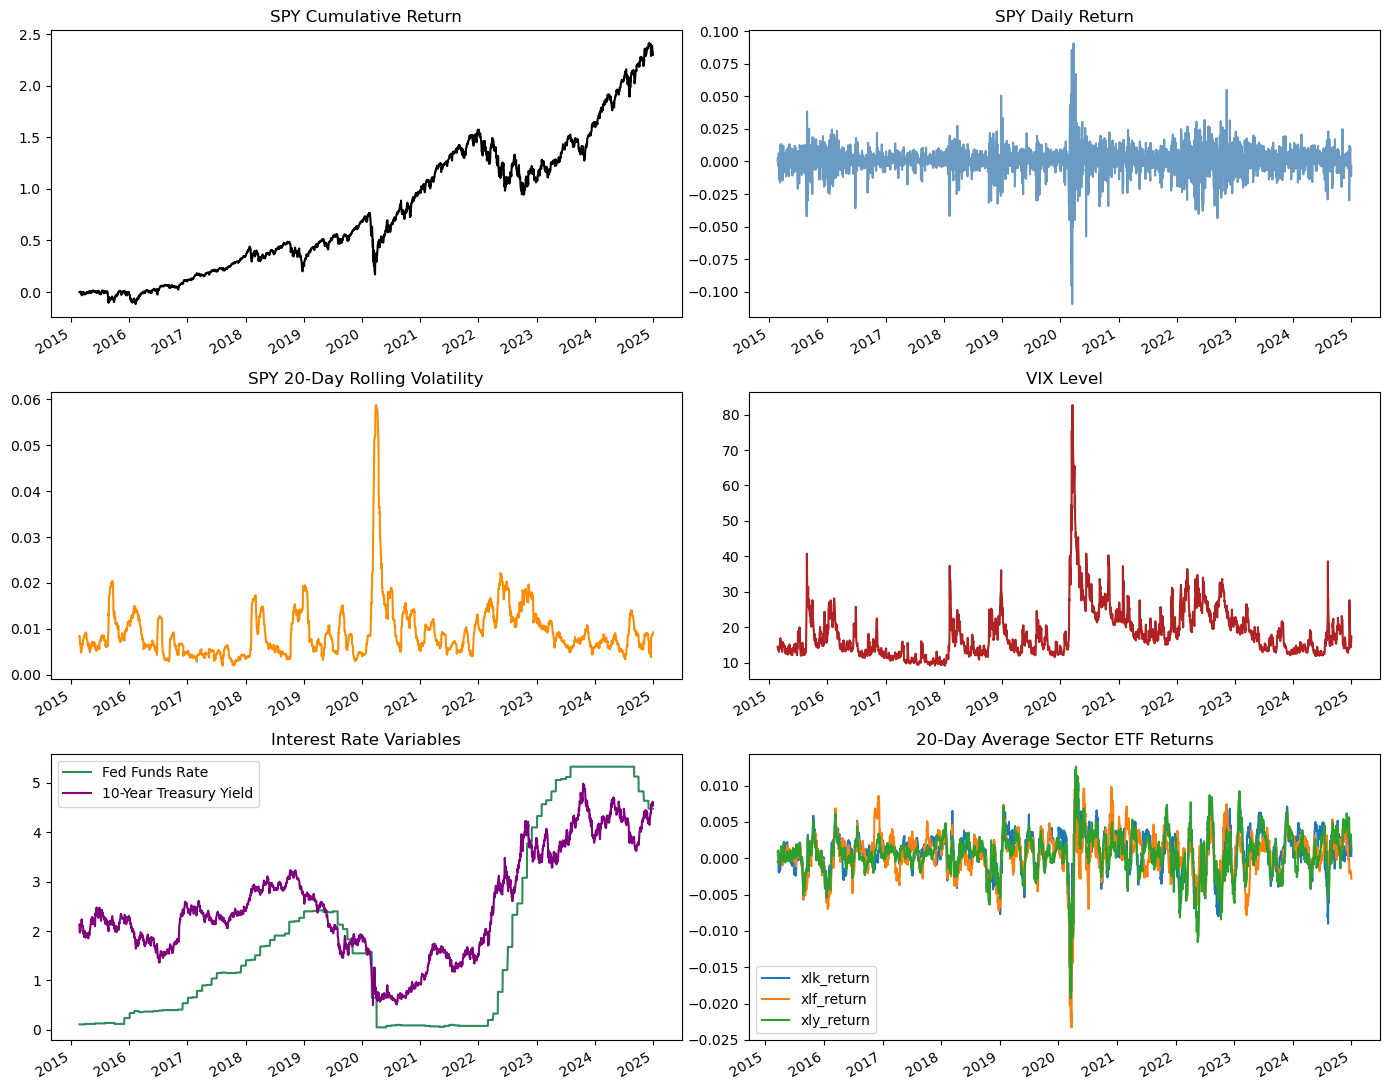

In [5]:
plot_df = df.copy()
plot_df["spy_cumulative_return"] = (1 + plot_df["spy_return"]).cumprod() - 1

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.ravel()

plot_df["spy_cumulative_return"].plot(ax=axes[0], color="black", title="SPY Cumulative Return")
plot_df["spy_return"].plot(ax=axes[1], color="steelblue", alpha=0.8, title="SPY Daily Return")
plot_df["spy_vol_20"].plot(ax=axes[2], color="darkorange", title="SPY 20-Day Rolling Volatility")
plot_df["vix_level"].plot(ax=axes[3], color="firebrick", title="VIX Level")

if "fed_funds_rate" in plot_df.columns:
    plot_df["fed_funds_rate"].plot(ax=axes[4], color="seagreen", label="Fed Funds Rate")
plot_df["ten_year_yield"].plot(ax=axes[4], color="purple", label="10-Year Treasury Yield")
axes[4].set_title("Interest Rate Variables")
axes[4].legend()

sector_cols = [col for col in ["xlk_return", "xlf_return", "xly_return"] if col in plot_df.columns]
plot_df[sector_cols].rolling(20).mean().plot(ax=axes[5], title="20-Day Average Sector ETF Returns")

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()
plt.show()
figure_caption(1, "Time-series summary of SPY returns, volatility, VIX, interest rates, and sector ETF returns.")


<div style="page-break-before: always;"></div>

## 3.3 Feature Correlation

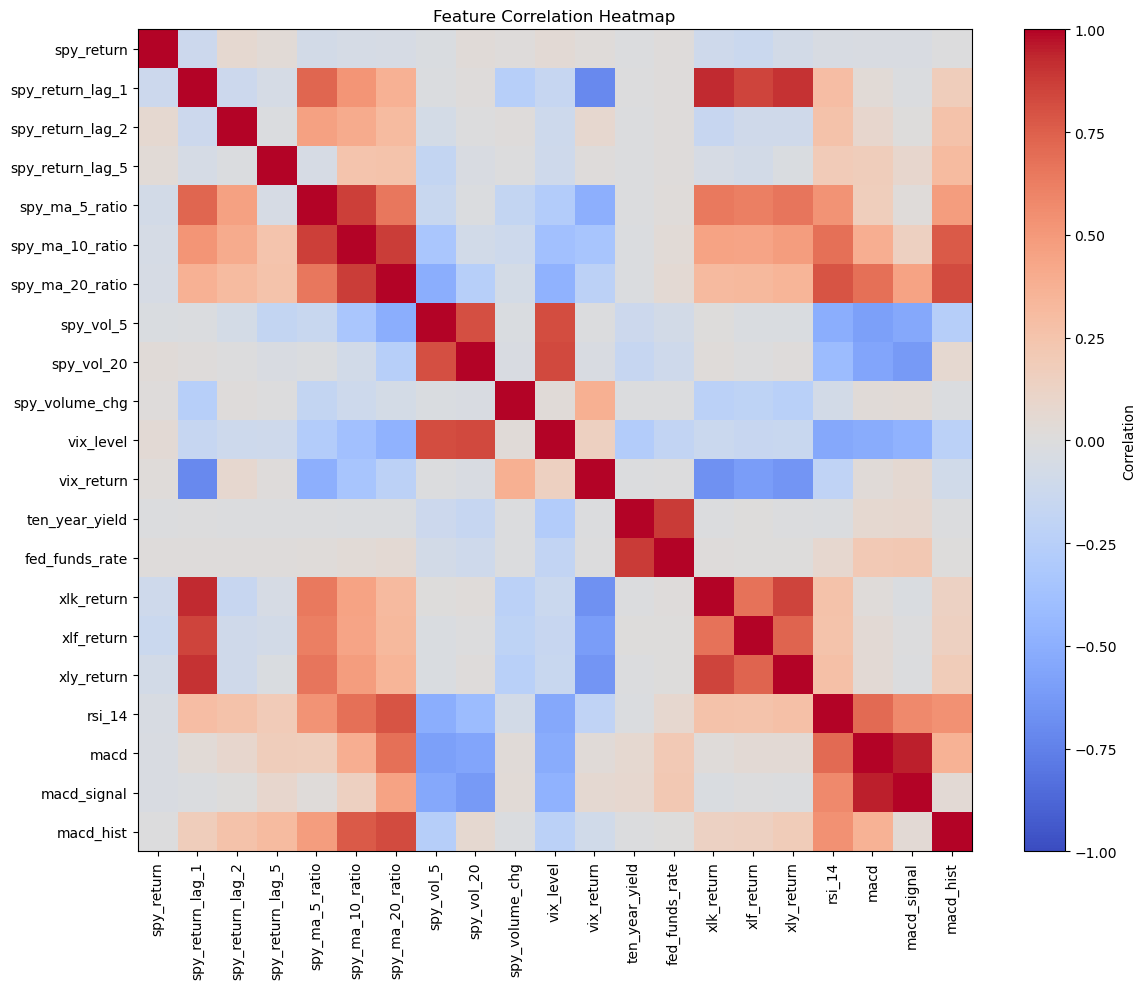

In [54]:
corr = df[feature_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
figure_caption(2, "Correlation heatmap for the full modeling feature set.")

<br>

In [44]:
corr_with_target = df[feature_cols + ["target"]].corr()["target"].drop("target")
corr_table = corr_with_target.abs().sort_values(ascending=False).to_frame("abs_corr_with_target")
corr_table["corr_with_target"] = corr_with_target.loc[corr_table.index]

display(
    corr_table.head(10)
    .style
    .set_caption("<strong>Table 11.</strong> Top 10 Features by Absolute Correlation with Target")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))


,abs_corr_with_target,corr_with_target
xlf_return,0.034613,0.034613
spy_return,0.033899,-0.033899
xlk_return,0.022353,0.022353
spy_volume_chg,0.016858,-0.016858
vix_return,0.016763,-0.016763
ten_year_yield,0.016382,-0.016382
spy_return_lag_5,0.015524,-0.015524
spy_return_lag_1,0.014261,0.014261
spy_vol_20,0.013993,-0.013993
fed_funds_rate,0.013937,0.013937


# 4. Methodology

## 4.1 Overview of Models and Validation Procedure

This project uses supervised machine learning classification models to predict the next-day return direction of SPY. The target variable equals 1 if the next-day SPY return is positive and 0 otherwise. All models use the same cleaned dataset, the same feature set, and the same target variable so that their results can be compared fairly.

We compare four models: Logistic Regression, Support Vector Machine, Random Forest, and K-Nearest Neighbors. These models represent different approaches to classification. Logistic Regression is a linear baseline model, SVM is a margin-based classifier that can capture nonlinear decision boundaries, Random Forest is a tree-based ensemble method, and KNN is a distance-based nonparametric method.

Because the observations are ordered by trading date, we use a chronological train-validation-test split instead of a random split. The training set is used to fit the models, the validation set is used to choose hyperparameters, and the test set is reserved for final performance evaluation. This prevents future observations from being used to predict earlier observations and better reflects a realistic financial forecasting setting.

To make the comparison fair, each group member should use the same `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, and `y_test` created in the code below. Each model may have its own preprocessing and hyperparameter choices, but the final performance should be reported on the same test set. Model performance will be evaluated using accuracy, AUC, and the confusion matrix.

Feature scaling is handled model by model. Logistic Regression, SVM, and KNN should use `StandardScaler` inside a `Pipeline` because these methods are sensitive to feature scale. Random Forest does not require standardization because tree-based models split observations based on feature thresholds and are generally not affected by variable magnitude.


In [46]:
TRAIN_END = "2020-12-31"
VAL_END = "2022-12-31"

X = df[feature_cols]
y = df["target"]

train = df[df.index <= TRAIN_END]
val = df[(df.index > TRAIN_END) & (df.index <= VAL_END)]
test = df[df.index > VAL_END]

X_train, y_train = train[feature_cols], train["target"]
X_val, y_val = val[feature_cols], val["target"]
X_test, y_test = test[feature_cols], test["target"]

split_summary = pd.DataFrame({
    "Period":         ["Train", "Validation", "Test"],
    "Start Date":     [train.index.min().date(), val.index.min().date(), test.index.min().date()],
    "End Date":       [train.index.max().date(), val.index.max().date(), test.index.max().date()],
    "Observations":   [len(train), len(val), len(test)],
    "Up Days":        [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Down/Flat Days": [int((1 - y_train).sum()), int((1 - y_val).sum()), int((1 - y_test).sum())],
    "% Up":           [f"{y_train.mean():.1%}", f"{y_val.mean():.1%}", f"{y_test.mean():.1%}"],
})

display(
    split_summary
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 12.</strong> Train / Validation / Test Split Summary")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))

Period,Start Date,End Date,Observations,Up Days,Down/Flat Days,% Up
Train,2015-02-23,2020-12-31,1476,811,665,54.9%
Validation,2021-01-04,2022-12-30,503,255,248,50.7%
Test,2023-01-03,2024-12-31,502,288,214,57.4%


In [9]:
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

fitted_models = {}
model_results = []

def positive_class_score(model, X_data):
    """Return continuous scores for class 1, used for AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return model.predict(X_data)

def tune_on_validation(base_model, param_grid):
    """Choose hyperparameters using validation AUC, then refit on train + validation."""
    best_params = None
    best_val_auc = -np.inf
    
    for params in ParameterGrid(param_grid):
        candidate = clone(base_model).set_params(**params)
        candidate.fit(X_train, y_train)
        val_score = positive_class_score(candidate, X_val)
        val_auc = roc_auc_score(y_val, val_score)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_params = params
    
    final_model = clone(base_model).set_params(**best_params)
    final_model.fit(X_train_val, y_train_val)
    return final_model, best_params, best_val_auc

def evaluate_on_test(name, model, best_params=None, val_auc=None):
    """Evaluate one fitted model on the common test set."""
    y_pred = model.predict(X_test)
    y_score = positive_class_score(model, X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    result = {
        "model": name,
        "best_params": best_params,
        "validation_auc": val_auc,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_auc": roc_auc_score(y_test, y_score),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1]
    }
    
    fitted_models[name] = model
    model_results.append(result)
    return pd.DataFrame([result])


## 4.2 : Models
### 4.2.1 : Logistic Regression (Anna Chen)


**Motivation**  
Logistic Regression is included as the baseline classification model. It is simple, interpretable, and commonly used for binary prediction problems. In this project, it estimates the probability that the next-day SPY return will be positive using the same lagged market, macro, sector, and technical indicators used by the other models. The model can be written as

$$P(Y_t = 1 \mid X_t) = \frac{1}{1 + \exp[-(\beta_0 + X_t^\top \beta)]},$$

so each coefficient describes how a one-standard-deviation change in a predictor is associated with the log-odds of an up day, holding the other predictors fixed.

**Model description**  
We use a `LogisticRegression` model inside a `Pipeline` with `StandardScaler`. Scaling is necessary because Logistic Regression is sensitive to feature magnitude, and variables such as VIX level, interest rates, and daily returns are measured on different scales. The validation search considers different values of regularization strength `C`, penalty type (`L1` or `L2`), and `class_weight`. The best configuration is selected using validation AUC, which evaluates the ranking quality of predicted probabilities without depending on a fixed 0.5 classification threshold. After the best hyperparameters are selected, the final Logistic Regression model is refit on the combined training and validation periods before being evaluated on the held-out test set.

**Why this method is appropriate**  
Logistic Regression is useful for this project because it provides a transparent linear benchmark against more flexible models such as KNN, Random Forest, and SVM. We do not fix `class_weight="balanced"` in advance; instead, both `class_weight=None` and `class_weight="balanced"` are compared on the validation set. This supports the modeling choice with empirical validation rather than assuming that class weighting is always appropriate. Because all predictors are standardized inside the pipeline, coefficient magnitudes are comparable across features; the coefficient plot is therefore used as an interpretability diagnostic rather than as evidence of causal relationships. A limitation is that Logistic Regression assumes an approximately linear relationship between the predictors and the log-odds of an up day, so nonlinear effects and feature interactions may not be captured unless they are explicitly engineered.


#### 1. Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=42
    ))
])

logit_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"],
}

logit_records = []
for params in ParameterGrid(logit_param_grid):
    candidate = clone(logit_model).set_params(**params)
    candidate.fit(X_train, y_train)
    val_pred = candidate.predict(X_val)
    val_score = positive_class_score(candidate, X_val)
    logit_records.append({
        "C": params["model__C"],
        "Penalty": params["model__penalty"].upper(),
        "Class Weight": params["model__class_weight"] or "None",
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Validation Balanced Accuracy": balanced_accuracy_score(y_val, val_pred),
        "Validation AUC": roc_auc_score(y_val, val_score),
    })

logit_tuning_results = pd.DataFrame(logit_records).sort_values(
    "Validation AUC", ascending=False
).reset_index(drop=True)

logit_best_row = logit_tuning_results.iloc[0]
logit_best_params = {
    "model__C": logit_best_row["C"],
    "model__penalty": logit_best_row["Penalty"].lower(),
    "model__class_weight": None if logit_best_row["Class Weight"] == "None" else "balanced",
}
logit_val_auc = logit_best_row["Validation AUC"]

logit_best_model = clone(logit_model).set_params(**logit_best_params)
logit_best_model.fit(X_train_val, y_train_val)

logit_result = evaluate_on_test(
    name="Logistic Regression",
    model=logit_best_model,
    best_params=logit_best_params,
    val_auc=logit_val_auc
)

logit_weight_comparison = (
    logit_tuning_results
    .groupby("Class Weight", as_index=False)
    .agg(
        **{
            "Best Validation AUC": ("Validation AUC", "max"),
            "Best Validation Balanced Accuracy": ("Validation Balanced Accuracy", "max"),
        }
    )
)
logit_weight_comparison[[
    "Best Validation AUC",
    "Best Validation Balanced Accuracy",
]] = logit_weight_comparison[[
    "Best Validation AUC",
    "Best Validation Balanced Accuracy",
]].round(4)

logit_test_pred_for_summary = logit_best_model.predict(X_test)
logit_test_score_for_summary = positive_class_score(logit_best_model, X_test)
logit_test_cm = confusion_matrix(y_test, logit_test_pred_for_summary)

logit_final_summary = pd.DataFrame([{
    "Model": "Logistic Regression",
    "C": logit_best_params["model__C"],
    "Penalty": logit_best_params["model__penalty"].upper(),
    "Class Weight": logit_best_params["model__class_weight"] or "None",
    "Validation AUC": logit_val_auc,
    "Test Accuracy": accuracy_score(y_test, logit_test_pred_for_summary),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, logit_test_pred_for_summary),
    "Test Precision": precision_score(y_test, logit_test_pred_for_summary, zero_division=0),
    "Test Recall": recall_score(y_test, logit_test_pred_for_summary, zero_division=0),
    "Test F1": f1_score(y_test, logit_test_pred_for_summary, zero_division=0),
    "Test AUC": roc_auc_score(y_test, logit_test_score_for_summary),
    "TN": logit_test_cm[0, 0],
    "FP": logit_test_cm[0, 1],
    "FN": logit_test_cm[1, 0],
    "TP": logit_test_cm[1, 1],
}])
logit_metric_cols = [
    "Validation AUC", "Test Accuracy", "Test Balanced Accuracy",
    "Test Precision", "Test Recall", "Test F1", "Test AUC"
]
logit_final_summary[logit_metric_cols] = (
    logit_final_summary[logit_metric_cols].round(4)
)
logit_final_display = logit_final_summary.T.reset_index()
logit_final_display.columns = ["Item", "Value"]

display(
    logit_weight_comparison
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 13.</strong> Logistic Regression Class Weight Comparison")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))


,Class Weight,Best Validation AUC,Best Validation Balanced Accuracy
0,None,0.533700,0.527200
1,balanced,0.534500,0.530100


In [49]:
display(
    logit_final_display
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 14.</strong> Logistic Regression Final Test Summary")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))

Item,Value
Model,Logistic Regression
C,1.000000
Penalty,L2
Class Weight,balanced
Validation AUC,0.534500
Test Accuracy,0.452200
Test Balanced Accuracy,0.510600
Test Precision,0.622600
Test Recall,0.114600
Test F1,0.193500


<div style="page-break-before: always;"></div>

#### 2. Visualizations

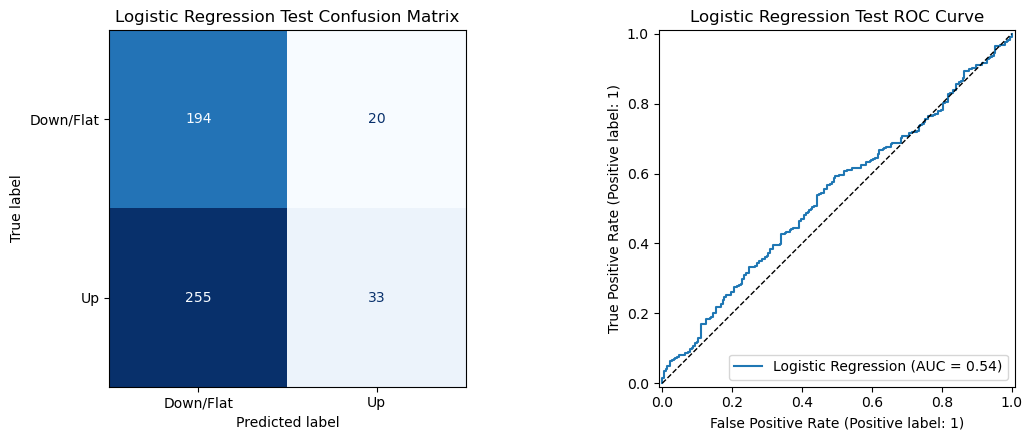

In [12]:
logit_coefficients = pd.Series(
    logit_best_model.named_steps["model"].coef_[0],
    index=feature_cols
).sort_values(key=lambda x: x.abs(), ascending=False)

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


logit_pred = logit_best_model.predict(X_test)
logit_score = positive_class_score(logit_best_model, X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logit_pred,
    display_labels=["Down/Flat", "Up"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Logistic Regression Test Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    logit_score,
    name="Logistic Regression",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("Logistic Regression Test ROC Curve")

plt.tight_layout()
plt.show()
figure_caption(3, "Logistic Regression confusion matrix and ROC curve on the test set.")


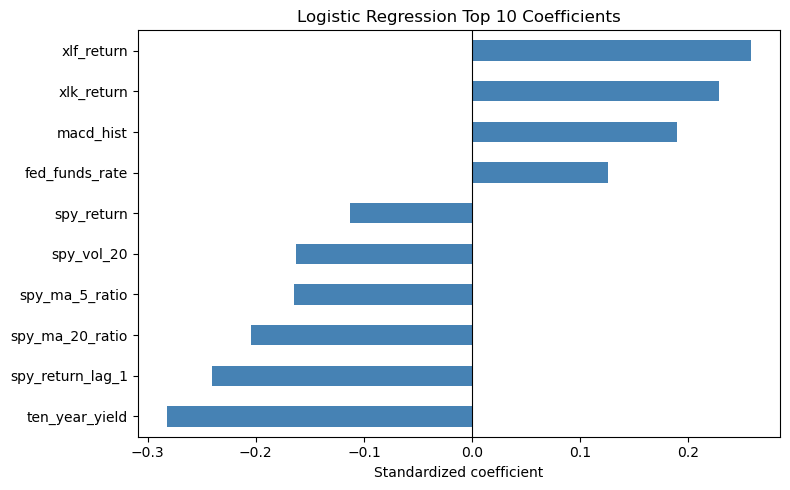

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
logit_coefficients.head(10).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Top 10 Coefficients")
ax.set_xlabel("Standardized coefficient")
plt.tight_layout()
plt.show()
figure_caption(4, "Top 10 Logistic Regression coefficients by absolute standardized magnitude.")

**Logistic Regression results interpretation**  
Table 14 and Figure 3 show that the final Logistic Regression model has a test AUC of 0.5385, which is slightly above the random-ranking benchmark of 0.50 but still indicates weak out-of-sample predictive signal. The test accuracy is 0.4522 and the balanced accuracy is 0.5106, so the model does not produce strong classification performance at the default threshold. However, its precision is 0.6226 while its recall is only 0.1146, meaning that when the model predicts an up day it is relatively selective, but it misses many actual up days. This pattern is also visible in the confusion matrix, where the number of false negatives is large relative to true positives.

Figure 4 provides an interpretability check based on standardized coefficients. Because the features are scaled before fitting, the coefficient magnitudes can be compared across predictors. The largest coefficients identify the variables with the strongest linear association with the predicted log-odds of an up day in this fitted model. These coefficients should be interpreted as predictive associations within the model rather than causal effects. Overall, Logistic Regression provides a transparent benchmark and produces the highest test AUC among the current model set, but the magnitude of the AUC suggests that any next-day direction signal remains limited.


### 4.2.2 : KNN (Yue Lu)



**Motivation**  
K-Nearest Neighbors is included as a nonparametric benchmark. Unlike Logistic Regression, KNN does not impose a linear relationship between the predictors and the probability of an up day. Instead, it classifies a new observation based on the historical observations that are most similar in feature space.

**Model description**  
We use a `KNeighborsClassifier` inside a `Pipeline` with `StandardScaler`. Scaling is necessary because KNN relies on distance calculations, and unscaled variables such as VIX level or interest rates could otherwise dominate return-based features. The validation search considers different values of `n_neighbors`, distance weighting schemes, and distance metrics. The best configuration is chosen using validation performance before evaluating on the test set.

**Why this method is appropriate**  
KNN is useful for this project because it can capture local patterns without specifying a parametric model. If days with similar volatility, momentum, and macro conditions tend to have similar next-day directions, KNN may identify those relationships. It also provides a contrast to the linear baseline and tree-based ensemble model.


#### 1. Model

In [63]:
from sklearn import set_config
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

set_config(enable_cython_pairwise_dist=False)

knn_grid = []
for n_neighbors in [3, 5, 7, 9, 11, 15, 21, 31, 41, 51]:
    for weights in ["uniform", "distance"]:
        for metric in ["minkowski", "manhattan"]:
            knn = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(
                    n_neighbors=n_neighbors,
                    weights=weights,
                    metric=metric,
                )),
            ])
            knn.fit(X_train, y_train)

            val_pred = knn.predict(X_val)
            val_prob = knn.predict_proba(X_val)[:, 1]

            knn_grid.append({
                "n_neighbors": n_neighbors,
                "weights": weights,
                "metric": metric,
                "val_f1": f1_score(y_val, val_pred, zero_division=0),
                "val_auc": roc_auc_score(y_val, val_prob),
            })

knn_tuning_results = pd.DataFrame(knn_grid).sort_values(
    ["val_f1", "val_auc"],
    ascending=False,
).reset_index(drop=True)

best_knn_params = knn_tuning_results.loc[0, ["n_neighbors", "weights", "metric"]].to_dict()
best_knn_params["n_neighbors"] = int(best_knn_params["n_neighbors"])

best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(**best_knn_params)),
])
best_knn.fit(X_train, y_train)

knn_val_pred = best_knn.predict(X_val)
knn_val_prob = best_knn.predict_proba(X_val)[:, 1]
knn_test_pred = best_knn.predict(X_test)
knn_test_prob = best_knn.predict_proba(X_test)[:, 1]

def classification_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
    }

knn_results = pd.DataFrame([
    {"sample": "Validation", **classification_metrics(y_val, knn_val_pred, knn_val_prob)},
    {"sample": "Test", **classification_metrics(y_test, knn_test_pred, knn_test_prob)},
])

In [64]:
print("Best KNN Parameters:")
print(best_knn_params)

display(
    knn_tuning_results.head().round(4)
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 15.</strong> Top 5 KNN Validation Results")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))


Best KNN Parameters:
{'n_neighbors': 51, 'weights': 'uniform', 'metric': 'manhattan'}


n_neighbors,weights,metric,val_f1,val_auc
51,uniform,manhattan,0.581300,0.479900
51,distance,manhattan,0.580800,0.478300
41,uniform,minkowski,0.570900,0.484700
41,distance,manhattan,0.570500,0.490300
41,uniform,manhattan,0.567100,0.493300


In [53]:
display(
    knn_results.round(4)
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 16.</strong> KNN Validation and Test Performance")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 20px;'></div>"))

sample,accuracy,balanced_accuracy,precision,recall,f1,auc
Validation,0.497000,0.495600,0.503300,0.600000,0.547400,0.495500
Test,0.533900,0.509700,0.580800,0.673600,0.623800,0.512200


#### 2. Visualizations

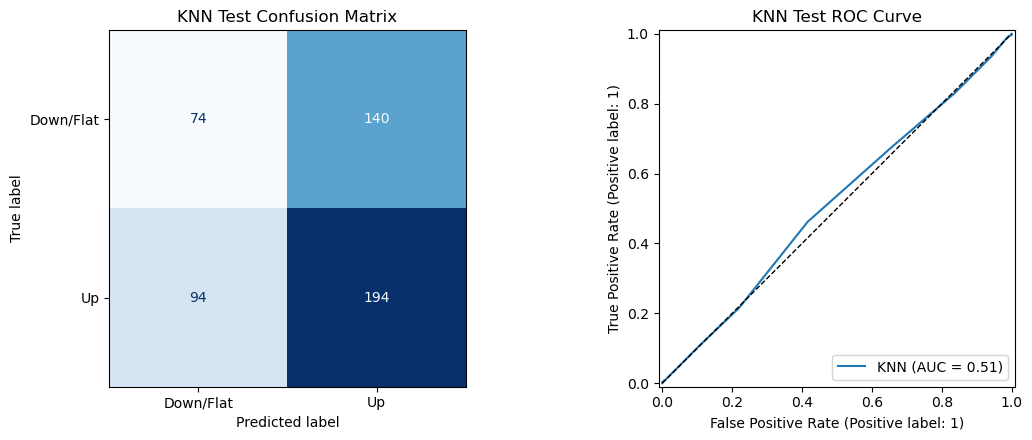

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_test_pred,
    display_labels=["Down/Flat", "Up"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("KNN Test Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    knn_test_prob,
    name="KNN",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("KNN Test ROC Curve")

plt.tight_layout()
plt.show()
figure_caption(5, "KNN confusion matrix and ROC curve on the test set.")

### 4.2.3 : Random Forest (David Zhang)

**Motivation**  
Since next-day SPY direction prediction involves numerous features spanning from macroeconomic conditions to technical indicators, a feature set whose joint predictive structure is unlikely to be linear or additive. Random Forest captures nonlinear interactions among these variables automatically. It also requires no feature standardization, unlike logistic regression and SVM, which eliminates a potential source of leakage from the preprocessing step. For a noisy, short-horizon prediction task with over 1000 training observations, ensemble averaging across many bootstrapped trees meanwhile reduces prediction variance compared to a single decision tree.

**Model description**  
Random Forest builds many decision trees on bootstrap samples of the training data and averages their predicted class probabilities. At each node, only a random subset of features is considered for splitting, which decorrelates the trees and reduces ensemble variance.

| Hyperparameter | Function | Candidates |
|----------------|------------|------------|
| `n_estimators` | Number of trees: more trees, lower variance | 200, 300, 500 |
| `max_depth` | Maximum tree depth: limits overfitting | 3, 5, 8, `None` |
| `min_samples_leaf` | Minimum observations per leaf: smooths decision boundary | 1, 5, 10 |
| `max_features` | Features considered per split: decorrelates trees | `sqrt`, 0.5 |
| `class_weight` | Reweights minority class: addresses class imbalance |`None`, `balanced` |
| `ccp_alpha` | Post-growth pruning: simplifies trees | np.linspace(0.0, 0.02, 6) |

**Why this method is appropriate**  
In general, random Forest suits our task for three reasons. First, it requires no StandardScaler and eliminating a potential leakage risk present in logistic regression and SVM. It captures nonlinear interactions across the 21 heterogeneous features without manual specification. Besides, its ensemble structure reduces prediction variance in a high-noise, small-sample setting where daily equity return prediction is inherently difficult (Ansah, 2022). Lastly, the mild class imbalance of roughly 55% Up versus 45% Down days is addressed by including class-weight as a tuned hyperparameter, letting validation AUC determine empirically whether reweighting improves out-of-sample performance.


#### 1. Data Processing

In [ ]:
#Check data balance
np.random.seed(42)

rf_balance_summary = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Validation": y_val.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index(),
}).T

rf_balance_summary.columns = ["Down/Flat", "Up"]
rf_balance_summary.index.name = "Split" 

display(
    rf_balance_summary.round(4)
    .style
    .set_caption("<strong>Table 17.</strong> Data Distribution by Split")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)


,Down/Flat,Up
Split,,
Train,0.450500,0.549500
Validation,0.493000,0.507000
Test,0.426300,0.573700


The class balance table shows whether Up and Down/Flat days are evenly represented across the train, validation, and test periods. Because the class proportions are not exactly equal and may shift across time periods, the following Random Forest tuning grid includes class weight argument. This allows validation AUC to determine whether reweighting the less frequent class improves out-of-sample ranking performance.

#### 2. Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5],
    "class_weight": [None, "balanced"],
    "ccp_alpha": np.linspace(0.0, 0.02, 6),
}

rf_best_model, rf_best_params, rf_best_val_auc = tune_on_validation(
    rf_model,
    rf_param_grid
)

rf_result = evaluate_on_test(
    name="Random Forest",
    model=rf_best_model,
    best_params=rf_best_params,
    val_auc=rf_best_val_auc
)

rf_test_pred = rf_best_model.predict(X_test)
rf_test_prob = positive_class_score(rf_best_model, X_test)
y_score_rf = rf_test_prob

display(
    rf_result.round(4)
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 18.</strong> Model Evaluation")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)
print("Selected RF parameters:", rf_best_params)


model,best_params,validation_auc,test_accuracy,test_auc,tn,fp,fn,tp
Random Forest,"{'ccp_alpha': np.float64(0.004), 'class_weight': None, 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 200}",0.561700,0.426300,0.499000,214,0,288,0


Selected RF parameters: {'ccp_alpha': np.float64(0.004), 'class_weight': None, 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 200}


After model setup, training, and train/test evaluation, the tuned Random Forest achieves a validation AUC of 0.5617, suggesting weak ranking ability during the validation period. However, its test AUC drops to 0.4988 and its test accuracy is only 0.4263, indicating that the validation relationship does not generalize to the 2023-2024 test period. The result ultimately comes down to how the selected hyperparameters compound on each other rather than any single parameter being problematic in isolation.

With max_depth=3, each tree can only partition the feature space into 8 coarse regions across 21 features. It is already a very blunt instrument for a noisy prediction task. Stacking min_samples_leaf=10 on top makes it worse, blocking many splits before they even happen. Then ccp_alpha=0.004 prunes away what little remains, since most splits in a dataset where the strongest feature correlation is only |r| ≈ 0.07 produce such marginal impurity reductions that they fall below the pruning threshold anyway. By the time a tree is fully grown, it is shallower and simpler than the already-shallow max_depth=3 setting suggests.

With class_weight=None providing no additional push toward recovering either class, averaging 200 of these heavily regularized trees produces predicted probabilities that cluster in a narrow band between 0.45 and 0.50 for every single test day without once crossing the decision boundary. The model is not confidently predicting Down/Flat. Instead, it is essentially guessing on every observation, and that uncertainty just happens to land consistently on the wrong side of 0.5.

#### 3. Visualizations

##### (1) Confusion Matrix & ROC curve

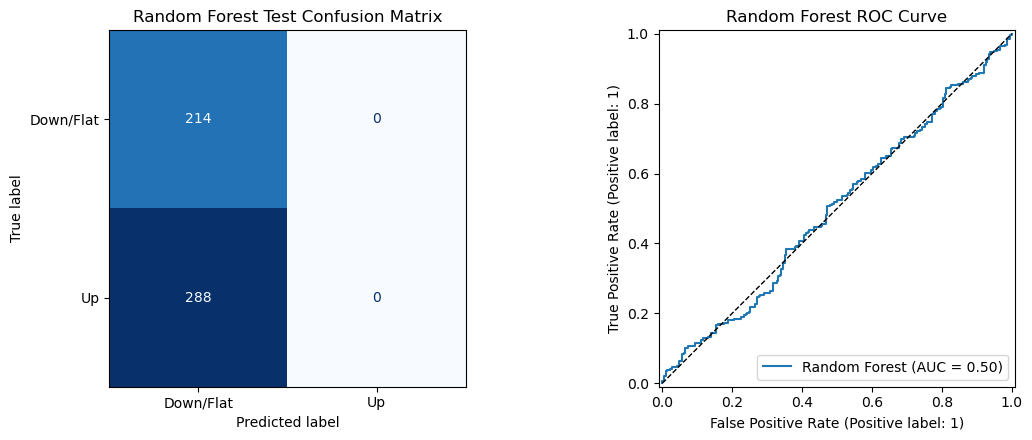

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test_pred,
    display_labels=["Down/Flat", "Up"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Random Forest Test Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    rf_test_prob,
    name="Random Forest",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("Random Forest ROC Curve")

plt.tight_layout()
plt.show()
figure_caption(6, "Random Forest confusion matrix and ROC curve on the test set.")

The confusion matrix clearly reveals the pattern that the classifier successfully classified all 214 down days correctly but failed to classify all 288 up days, classifying all observations as Down/Flat. In no case was the Up prediction made; hence, there were zero true and false positives. This is also evident from the ROC curve plot where the ROC line is plotted just below the diagonal at an AUC score of 0.49, meaning the classifier scores positive cases a little less effectively than random. Together, the two plots give a similar view regarding the performance of Random Forest over the test period from 2023-2024 that it was unable to classify any signals to distinguish up from down days.

##### (2) Feature Importances

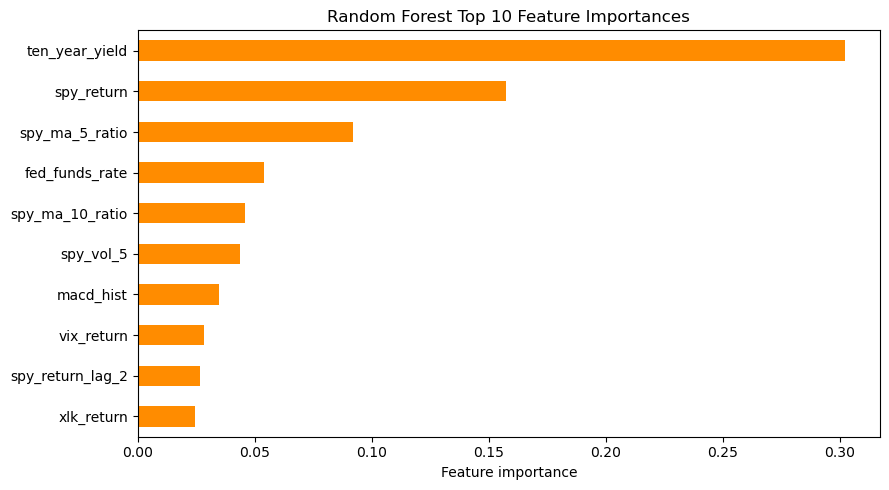

In [21]:
rf_importance = pd.Series(
    rf_best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
rf_importance.sort_values().plot(kind="barh", color="darkorange")
plt.title("Random Forest Top 10 Feature Importances")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()
figure_caption(7, "Top 10 Random Forest feature importances.")

Ten-year-yield stands out dramatically, accounting for nearly 0.49 of total importance. This is likely a statistical artifact rather than genuine predictive power. The ten-year yield is a slowly varying level variable ranging from roughly 1% to 5% across the sample, giving it many distinct split points at each tree node. Random Forest's Gini-based importance tends to favor variables with many unique values, since they offer more opportunities to reduce impurity at each split. In contrast, daily return features are small and noisy, offering fewer clean split opportunities. The dominance of ten-year-yield here is therefore more a reflection of how the RF scores importance than evidence that yields genuinely drive next-day SPY direction.

##### (3) Probability Series

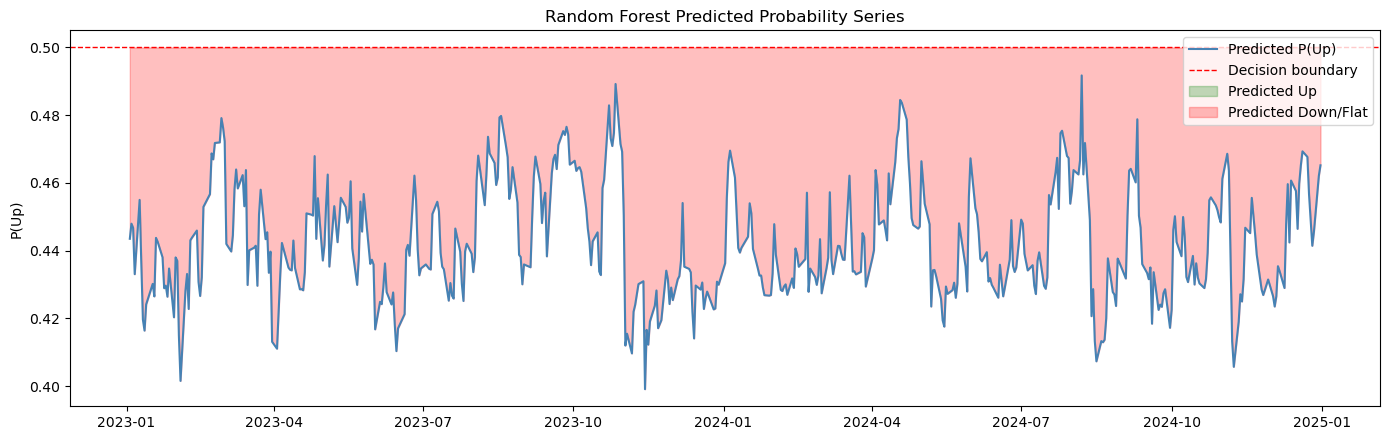

In [22]:
prob_series = pd.Series(rf_test_prob, index=X_test.index, name="P(Up)")

plt.figure(figsize=(14, 4.5))
plt.plot(prob_series, label="Predicted P(Up)", color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Decision boundary")
plt.fill_between(
    prob_series.index,
    0.5,
    prob_series,
    where=prob_series >= 0.5,
    alpha=0.25,
    color="green",
    label="Predicted Up",
)
plt.fill_between(
    prob_series.index,
    prob_series,
    0.5,
    where=prob_series < 0.5,
    alpha=0.25,
    color="red",
    label="Predicted Down/Flat",
)
plt.title("Random Forest Predicted Probability Series")
plt.ylabel("P(Up)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
figure_caption(8, "Random Forest predicted probability series on the test set.")

The predicted probability series tracks the model's daily confidence that SPY will close up, plotted over the entire 2023–2024 test period. Values above 0.5 would signal a predicted Up day (green), while values below 0.5 signal a predicted Down/Flat day (red). As a response to changing market environment, there should be observable swings around the point in question. In reality, what is plotted is something quite the contrary: predicted probability lies completely squeezed in a small space from 0.45 to 0.50 without ever exceeding the decision boundary. Thus, for the whole two years, one gets a perfectly red plot with no green spots on it. Lack of true positives in the confusion matrix may be visually supported by the certainty of the model, which does not vary much despite the activity on the market. Furthermore, flatness of the line under discussion proves poor calibration of the model because it treats all trading days equally in terms of forecasting certainty.

### 4.2.4 : SVM (Jiayuan Li)


**Motivation**  
SVM finds the maximum-margin hyperplane separating two classes in feature space, making it inherently resistant to noise — a desirable property when predicting daily return direction where signal-to-noise ratios are low. Its kernel trick allows the model to capture nonlinear structure without explicitly enumerating interaction terms.

**Model description**  
We train a binary SVC with two candidate kernels:

- **Linear**: $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$, controlled by regularisation parameter $C$.
- **RBF**: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp\!\left(-\gamma\,\|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$, capturing local nonlinear geometry.

The signed distance from the decision hyperplane (`decision_function`) is used as the ranking score for AUC, avoiding the internal cross-validation that Platt scaling would introduce — which would violate the strict chronological separation required for time-series evaluation.

**Hyperparameter tuning**  
Grid search is performed on the validation set (2021–2022); the configuration with the highest validation AUC is selected.

| Hyperparameter | Candidates |
|----------------|------------|
| `kernel` | `linear`, `rbf` |
| `C` | 0.01, 0.1, 1, 10, 100 |
| `gamma` | `scale`, `auto` (rbf only) |
| `class_weight` | `None`, `balanced` |

**Why this method is appropriate**  
- All features are standardised, satisfying SVM's scale-sensitivity requirement — with the scaler fitted on the training set only to prevent leakage.
- The max-margin objective generalises well in relatively high-dimensional settings (21 features, ~1,500 training observations).
- No distributional assumptions on returns are imposed.

#### 1. Model

In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

param_combos = [
    {'kernel': kernel, 'C': C, 'gamma': gamma, 'class_weight': cw}
    for kernel in ['linear', 'rbf']
    for C      in [0.01, 0.1, 1, 10, 100]
    for gamma  in (['scale'] if kernel == 'linear' else ['scale', 'auto'])
    for cw     in [None, 'balanced']
]

records = []
for p in param_combos:
    svc = SVC(**p, random_state=42)
    svc.fit(X_train_sc, y_train)
    pred  = svc.predict(X_val_sc)
    score = svc.decision_function(X_val_sc)
    records.append({**p,
                    'val_accuracy': accuracy_score(y_val, pred),
                    'val_auc'     : roc_auc_score(y_val, score),
                    'val_f1'      : f1_score(y_val, pred)})

best_idx    = max(range(len(records)), key=lambda i: records[i]['val_auc'])
best_params = param_combos[best_idx]
best_val    = records[best_idx]


tuning_df = pd.DataFrame(records).copy()
tuning_df['class_weight'] = tuning_df['class_weight'].fillna('None')
tuning_df = (tuning_df
             .sort_values('val_auc', ascending=False)
             .reset_index(drop=True)
             .rename(columns={'val_accuracy': 'Val Acc', 'val_auc': 'Val AUC', 'val_f1': 'Val F1'})
             [['kernel', 'C', 'gamma', 'class_weight', 'Val Acc', 'Val AUC', 'Val F1']]
             .round(4))

display(
    tuning_df.head(5)
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 19.</strong> Top 5 SVM Configurations by Validation AUC")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 10px;'></div>"))

kernel,C,gamma,class_weight,Val Acc,Val AUC,Val F1
linear,1.000000,scale,balanced,0.526800,0.535400,0.516300
linear,10.000000,scale,balanced,0.524900,0.530900,0.530500
linear,100.000000,scale,balanced,0.528800,0.530800,0.534400
linear,0.100000,scale,balanced,0.497000,0.526500,0.413000
linear,1.000000,scale,None,0.507000,0.524800,0.672800


#### 2. Model Evaluation

In [24]:
svm_best = SVC(**best_params, random_state=42)
svm_best.fit(X_train_sc, y_train)

y_pred  = svm_best.predict(X_test_sc)
y_score = svm_best.decision_function(X_test_sc)
cm      = confusion_matrix(y_test, y_pred)

test_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'AUC'      : roc_auc_score(y_test, y_score),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
}
svm_results = {'Model': 'SVM', **test_metrics}

print(f"\nSelected: kernel={best_params['kernel']},  C={best_params['C']},  "
      f"gamma={best_params['gamma']},  class_weight={best_params['class_weight']},  "
      f"Val AUC={best_val['val_auc']:.4f}")

metrics_table = pd.DataFrame({
    'Metric': list(test_metrics.keys()),
    'Test Score': [round(v, 4) for v in test_metrics.values()]
})

display(
    metrics_table
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 20.</strong> SVM Test-Set Performance")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 10px;'></div>"))


Selected: kernel=linear,  C=1,  gamma=scale,  class_weight=balanced,  Val AUC=0.5354


Metric,Test Score
Accuracy,0.571700
AUC,0.508900
Precision,0.585500
Recall,0.868100
F1 Score,0.699300


<div style="page-break-before: always;"></div>

#### 3. Visualizations

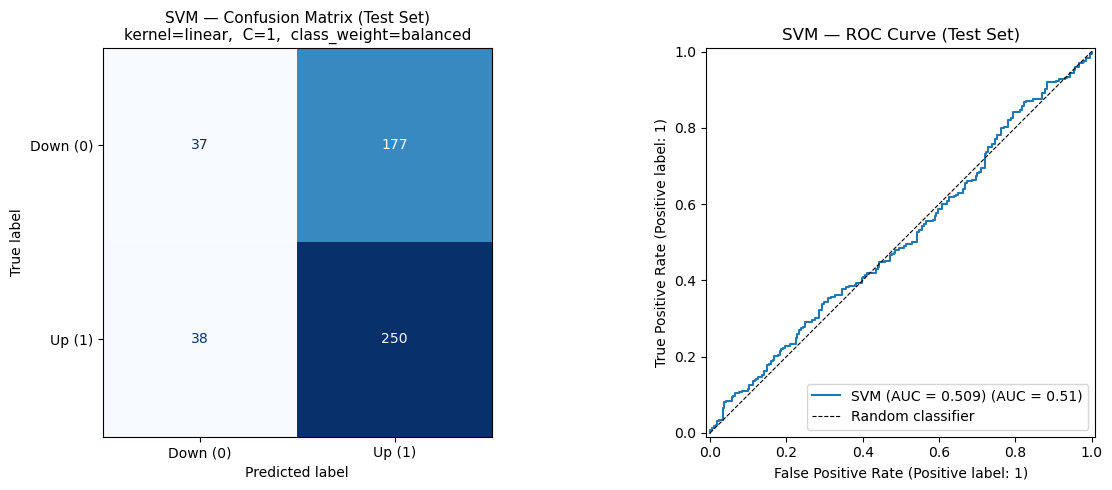

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f"SVM — Confusion Matrix (Test Set)\n"
    f"kernel={best_params['kernel']},  C={best_params['C']},  "
    f"class_weight={best_params['class_weight']}",
    fontsize=11)

RocCurveDisplay.from_predictions(
    y_test, y_score, ax=axes[1],
    name=f"SVM (AUC = {test_metrics['AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
axes[1].set_title('SVM — ROC Curve (Test Set)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()
figure_caption(9, "SVM confusion matrix and ROC curve on the test set.")

#### 4. SVM results interpretation

The final SVM model achieves the highest test accuracy and F1 score among the four models, with a test accuracy of 0.5717 and an F1 score of 0.6993. From the confusion matrix, the model correctly identifies many actual up days, with 250 true positives and only 38 false negatives. This explains its high recall of 0.8681. However, the model also produces 177 false positives, meaning that it often predicts an up day even when the market is actually down or flat. Therefore, the strong F1 score is partly driven by the model’s tendency to classify many observations as positive during a test period where up days are more common.

At the same time, the test AUC is only 0.5089, which is very close to the random benchmark of 0.50. This suggests that although SVM performs well under threshold-based metrics such as accuracy and F1, it does not strongly rank up days above down or flat days. The selected model uses a linear kernel with `C = 1` and `class_weight = balanced`, indicating that the validation set favored a simpler max-margin boundary rather than a more flexible RBF kernel. Overall, SVM is the best classifier in terms of test accuracy and recall, but its limited AUC shows that the predictive signal remains weak.

# 5. Results

The results below are from the common 2023-2024 test set. Hyperparameters are selected using the 2021-2022 validation set, while the test set is held out for final comparison.

## 5.1 Evaluation Metrics

Since this project is a binary classification problem, we use accuracy, precision, recall, F1 score, and AUC to evaluate the models. Accuracy measures the overall percentage of correct predictions. Precision measures how often the model is correct when it predicts an up day. Recall measures how many actual up days the model captures. F1 score combines precision and recall, so it is useful for comparing the balance between them. AUC measures how well the model ranks up days above down or flat days based on predicted probabilities.

The current initial results show that next-day SPY direction is difficult to predict with standard machine learning models. SVM has the highest test accuracy and F1 score in this version, largely because it predicts many up days during the 2023-2024 test period, when the market had more up days than down days. Logistic Regression has the highest test AUC, but the value is still only slightly above 0.50. Random Forest has the strongest validation AUC within its own grid search, but this does not carry over to the test period, which suggests that the validation relationship may not be stable.

Overall, these results show that different metrics give different views of model performance. Accuracy and F1 score favor SVM because it captures many up days in the test period. AUC favors Logistic Regression because it ranks observations slightly better than the other models. However, since most AUC values are close to 0.50, none of the models shows strong predictive power. This is important because a model can have a reasonable accuracy or F1 score while still having weak probability ranking ability.


## 5.2 Main Quantitative Results

In [26]:
def summarize_model(name, y_true, y_pred, y_score, validation_auc=None, best_params=None):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Model": name,
        "Validation AUC": validation_auc,
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Test Precision": precision_score(y_true, y_pred, zero_division=0),
        "Test Recall": recall_score(y_true, y_pred, zero_division=0),
        "Test F1": f1_score(y_true, y_pred, zero_division=0),
        "Test AUC": roc_auc_score(y_true, y_score),
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
        "Selected Parameters": best_params,
    }

logit_pred = logit_best_model.predict(X_test)
logit_score = positive_class_score(logit_best_model, X_test)

results_summary = pd.DataFrame([
    summarize_model("Logistic Regression", y_test, logit_pred, logit_score, logit_val_auc, logit_best_params),
    summarize_model("KNN", y_test, knn_test_pred, knn_test_prob, knn_results.loc[0, "auc"], best_knn_params),
    summarize_model("Random Forest", y_test, rf_test_pred, rf_test_prob, rf_best_val_auc, rf_best_params),
    summarize_model("SVM", y_test, y_pred, y_score, best_val["val_auc"], best_params),
])

metric_cols = [
    "Validation AUC", "Test Accuracy", "Test Balanced Accuracy",
    "Test Precision", "Test Recall", "Test F1", "Test AUC"
]
results_display = results_summary.copy()
results_display[metric_cols] = results_display[metric_cols].round(4)

performance_cols = [
    "Model", "Validation AUC", "Test Accuracy", "Test Balanced Accuracy",
    "Test Precision", "Test Recall", "Test F1", "Test AUC"
]
confusion_cols = ["Model", "TN", "FP", "FN", "TP"]

params_display = results_display[["Model", "Selected Parameters"]].copy()
params_display["Selected Parameters"] = params_display["Selected Parameters"].map(str)


### 5.2.1 Model Performances

In [27]:
display(
    results_display[performance_cols]
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 21.</strong> Model Performance Metrics on the Test Set")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 10px;'></div>"))

Model,Validation AUC,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1,Test AUC
Logistic Regression,0.534500,0.452200,0.510600,0.622600,0.114600,0.193500,0.538500
KNN,0.495500,0.533900,0.509700,0.580800,0.673600,0.623800,0.512200
Random Forest,0.561700,0.426300,0.500000,0.000000,0.000000,0.000000,0.499000
SVM,0.535400,0.571700,0.520500,0.585500,0.868100,0.699300,0.508900


### 5.2.2 Confusion Matrix Counts

In [28]:
display(
    results_display[confusion_cols]
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 22.</strong> Test-Set Confusion Matrix Counts by Model")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 10px;'></div>"))

Model,TN,FP,FN,TP
Logistic Regression,194,20,255,33
KNN,74,140,94,194
Random Forest,214,0,288,0
SVM,37,177,38,250


### 5.2.3 Model Hyperparameters

In [61]:
display(
    params_display.style
    .hide(axis="index")
    .set_properties(
        subset=["Selected Parameters"],
        **{"white-space": "normal", "text-align": "left"}
    )
    .set_caption("<strong>Table 23.</strong> Selected Model Hyperparameters")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("word-break", "break-word")]},
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        }
    ])
)

display(HTML("<div style='height: 10px;'></div>"))

Model,Selected Parameters
Logistic Regression,"{'model__C': np.float64(1.0), 'model__penalty': 'l2', 'model__class_weight': 'balanced'}"
KNN,"{'n_neighbors': 21, 'weights': 'uniform', 'metric': 'minkowski'}"
Random Forest,"{'ccp_alpha': np.float64(0.004), 'class_weight': None, 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 200}"
SVM,"{'kernel': 'linear', 'C': 1, 'gamma': 'scale', 'class_weight': 'balanced'}"


Logistic Regression has the highest test AUC among the four models, with a test AUC of 0.5385. This means it is slightly better than the other models at ranking up days above down or flat days. However, the AUC is still only a little above 0.50, so the improvement is limited. Its test accuracy is lower because it predicts fewer up days and misses many actual up days. This makes the model too conservative for this prediction task.

KNN has a test accuracy of 0.5339 and a test F1 score of 0.6238. Compared with Logistic Regression, KNN predicts more up days, so it has higher recall and a better F1 score. However, its test AUC is 0.5122, which is still close to random guessing. This means that KNN can classify some observations correctly, but it does not clearly separate up days from down or flat days.

Random Forest performs well during validation, but this result does not carry over to the test period. Its test AUC is 0.4988, which is almost the same as random guessing. This suggests that the patterns learned during validation may not be stable in the later test period. Since financial markets can change over time, a model that works well in one period may not perform well in another period.

SVM has the highest test accuracy and F1 score among the four models. Its test accuracy is 0.5717, and its test F1 score is 0.6993. This happens mainly because the SVM predicts many up days in the test period. Since the 2023-2024 test period had more up days than down days, this helps SVM achieve stronger classification results. However, its test AUC is only 0.5090, so the model is still not very strong at ranking observations.

Overall, SVM gives the best classification results based on accuracy and F1 score, while Logistic Regression gives the highest AUC. However, all models have AUC values close to 0.50, so the overall prediction problem remains difficult.

<div style="page-break-before: always;"></div>

## 5.3 Visualizations

### 5.3.1 ROC curves

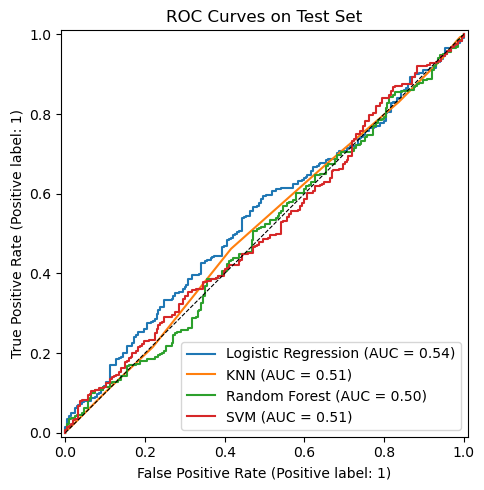

In [30]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, logit_score, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, knn_test_prob, ax=ax, name="KNN")
RocCurveDisplay.from_predictions(y_test, rf_test_prob, ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_score, ax=ax, name="SVM")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC Curves on Test Set")

plt.tight_layout()
plt.show()
figure_caption(10, "ROC curve comparison for all four models on the test set.")

The ROC curves show that all four models are close to the diagonal benchmark line. This means that the models do not have strong ability to rank up days above down or flat days. Logistic Regression has the highest AUC, but the improvement over 0.50 is small.

<div style="page-break-before: always;"></div>

### 5.3.2 Confusion Matrices

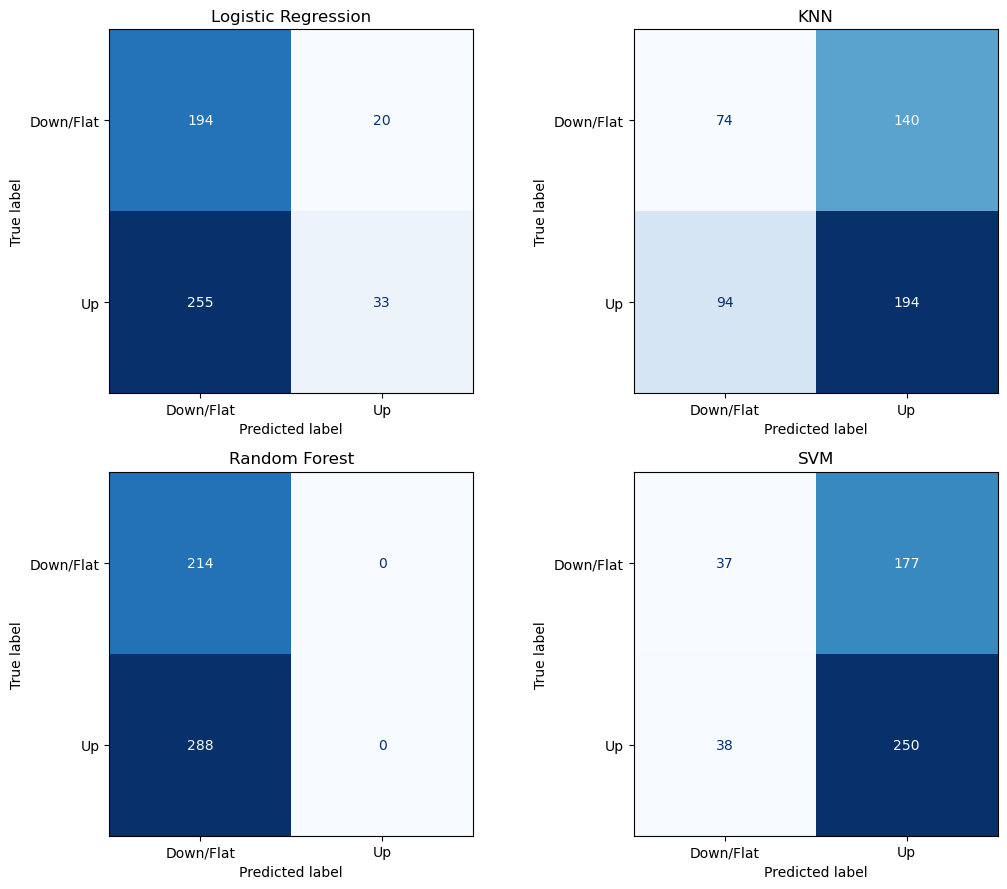

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
models_for_cm = [
    ("Logistic Regression", logit_pred),
    ("KNN", knn_test_pred),
    ("Random Forest", rf_test_pred),
    ("SVM", y_pred),
]

for ax, (name, pred) in zip(axes.ravel(), models_for_cm):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["Down/Flat", "Up"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()
figure_caption(11, "Confusion matrix comparison for all four models on the test set.")

The confusion matrices help explain why the models have different accuracy and F1 scores. Logistic Regression predicts fewer up days, so it misses many actual up days. SVM predicts more up days, which increases its recall and F1 score. KNN also predicts many up days, but its overall performance is weaker than SVM. Random Forest does not perform well on the test set, even though it had stronger validation results.

Overall, the visual results are consistent with the numerical results. SVM performs best in classification metrics such as accuracy and F1 score, but all models still have weak AUC values. This supports the idea that next-day SPY direction is hard to predict with the current features.

# 6. Discussions and Conclusions

In this project, we used several machine learning models to predict the next-day return direction of SPY (market indicators, volatility measures, sector returns, interest rate variables). Among all the models, SVM had the best overall performance. This may be because SVM tries to find a separating boundary between positive and non-positive return days, which can work better when the data is noisy and the signals are weak. However, even though SVM performed the best, its improvement over the benchmark was still small. Because of this, we do not think the result shows that SPY direction can be reliably predicted. Instead, it suggests that the model was only able to capture a limited amount of useful information.

From a financial perspective, this makes sense because short-term stock market movements are very hard to predict. Daily returns usually contain a lot of noise, and many price changes are caused by unexpected news, changes in investor sentiment, macroeconomic shocks, or random market movements. Although variables such as volatility and interest rates may provide some information, they are not enough to explain most next-day movements. SPY is also a very liquid and widely traded ETF, so public information is likely reflected in prices quickly. This is consistent with the Efficient Market Hypothesis, which suggests that asset prices already reflect available information and that short-term return prediction is limited (Fama, 1970).

The main practical implication is that our models do not provide strong evidence of a reliable trading signal. Even though SVM performed better than the other models, the improvement was too small to conclude that it could be used to make profitable trading decisions. In real markets, weak prediction results would become even less useful after considering transaction costs, bid-ask spreads, slippage, and risk management. This study also has some limitations. We only used historical public variables, used a fixed train-validation-test split, and evaluated the models mainly with classification metrics instead of actual trading performance. Future work could include richer data (news sentiment, macroeconomic announcements, intraday data, rolling-window testing). However, any improvement should still be judged carefully by whether it is stable out of sample, not just by a small increase in accuracy.



# Appendix. Reproducibility

The notebook can be reproduced by running all cells from top to bottom in the configured course environment. The data are downloaded from Yahoo Finance using `yfinance`; the Federal Funds Effective Rate is loaded from `FEDFUNDS.csv` when available, with a FRED URL fallback. The train-validation-test split is chronological and uses the same dates throughout the notebook.

Main software packages used in this project are Python, NumPy, pandas, matplotlib, yfinance, ta, and scikit-learn. Random seeds are set where applicable to make model fitting more reproducible, although small differences may still occur across package versions or data vendor updates.


In [32]:
import platform
import sklearn

versions = pd.DataFrame({
    "package": ["Python", "numpy", "pandas", "matplotlib", "yfinance", "ta", "scikit-learn"],
    "version": [
        platform.python_version(),
        np.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        yf.__version__,
        ta.__version__ if hasattr(ta, "__version__") else "not reported",
        sklearn.__version__,
    ]
})

display(
    versions
    .style
    .hide(axis="index")
    .set_caption("<strong>Table 24.</strong> Software Package Versions")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-weight", "normal")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto")
            ]
        }
    ])
)


package,version
Python,3.13.9
numpy,2.3.5
pandas,2.3.3
matplotlib,3.10.6
yfinance,1.4.1
ta,not reported
scikit-learn,1.7.2


# References

Ansah, K., Denwar, I. W., & Appati, J. K. (2022). Intelligent Models for Stock Price Prediction. Journal of Information Technology Research, 15(1), 1–17. https://doi.org/10.4018/jitr.298616

Aurélien Géron. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow. “O’Reilly Media, Inc.”

Fama, E. (1970). Efficient Capital markets: a Review of Theory and Empirical Work. The Journal of Finance, 25(2), 383–417. https://doi.org/10.2307/2325486

Federal Reserve Bank of St. Louis. (2024). Federal funds effective rate. FRED. https://fred.stlouisfed.org/series/FEDFUNDS

Jiao, Y., & Jakubowicz, J. (2017). Predicting stock movement direction with machine learning: An extensive study on S&P 500 stocks. 2017 IEEE International Conference on Big Data (Big Data). https://doi.org/10.1109/bigdata.2017.8258518

Rodriguez, F. S., P. Norouzzadeh, Anwar, Z., E. Snir, & Rahmani, B. (2024). A machine learning approach to predict the S&P 500 absolute percent change. Discover Artificial Intelligence, 4(1). https://doi.org/10.1007/s44163-024-00104-9

Yahoo Finance. (2024). SPY, XLK, XLF, XLY, VIX, TNX historical data. https://finance.yahoo.com